# Notebook 3 — Avaliação e Aprendizado Incremental

## Aula 1: Fundamentos do Data Drift em ML

### Objetivos
- Compreender o impacto do data drift nas métricas de avaliação
- Implementar **aprendizado incremental** com `partial_fit` para adaptação contínua
- Comparar desempenho: modelo estático vs. modelo adaptativo
- Simular o ciclo de **MLOps** para monitoramento e re-treinamento

### Teoria-Chave (Documento 04)

> Em vez de re-treinar do zero, podemos usar algoritmos que **aprendem
> continuamente**. Modelos treinados com SGD (`partial_fit`) permitem ajustar
> o modelo na medida em que chegam novos dados, sem descartar completamente
> o que já foi aprendido.
>
> — Seção *Saiba Mais — Adaptação e Mitigação*

> O ciclo contínuo — *monitorar → detectar → adaptar* — garante que o modelo
> permaneça útil e confiável ao longo do tempo.
>
> — Seção *Saiba Mais — Adaptação e Mitigação*

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import AdaptiveClassifier, DriftDetector
from src.training import train_model, incremental_train, train_with_drift_detection
from src.evaluation import (
    calculate_metrics,
    calculate_metrics_per_period,
    plot_accuracy_over_time,
    plot_confusion_matrix,
    plot_roc_curve,
)
from src.utils import save_model, load_model, save_metrics, ensure_dirs

sns.set_theme(style="whitegrid")
%matplotlib inline

ensure_dirs()

## 1. Carga dos Dados e Modelo Base

In [2]:
# Preparação dos dados
preprocessor = DataPreprocessor(random_state=42)
data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(data_path)
else:
    df = preprocessor.generate_synthetic_data(n_samples=10_000)
    preprocessor.save_data(df, data_path)

# Divisão temporal
df_train, df_test = preprocessor.split_by_period(
    df, train_periods=[1, 2], test_periods=[3, 4, 5]
)

X_train, y_train = preprocessor.prepare_features(df_train, fit=True)
X_test, y_test = preprocessor.prepare_features(df_test, fit=False)

# Treina ou carrega modelo base
model_path = Path.cwd().parent / "outputs" / "models" / "model_base.joblib"
if model_path.exists():
    model_static = load_model(model_path)
    print("Modelo base carregado")
else:
    model_static = train_model(X_train, y_train)
    save_model(model_static, model_path)
    print("Modelo base treinado e salvo")

print(f"Acurácia no treino: {model_static.score(X_train, y_train):.4f}")
print(f"Acurácia no teste (com drift): {model_static.score(X_test, y_test):.4f}")

Modelo base carregado
Acurácia no treino: 0.9062
Acurácia no teste (com drift): 0.8973


## 2. Avaliação Detalhada do Modelo Estático

Conforme a seção *Consequências do Data Drift para Modelos de ML*,
o modelo estático sofre degradação progressiva.

In [3]:
# Métricas detalhadas no conjunto de teste
y_pred_test = model_static.predict(X_test)
y_proba_test = model_static.predict_proba(X_test)[:, 1]

metrics_static = calculate_metrics(y_test, y_pred_test, y_proba_test)

print("Métricas do Modelo Estático no Teste (períodos 3-5):")
for k, v in metrics_static.items():
    print(f"  {k}: {v:.4f}")

Métricas do Modelo Estático no Teste (períodos 3-5):
  accuracy: 0.8973
  precision: 0.9818
  recall: 0.8852
  f1: 0.9310
  auc: 0.9747


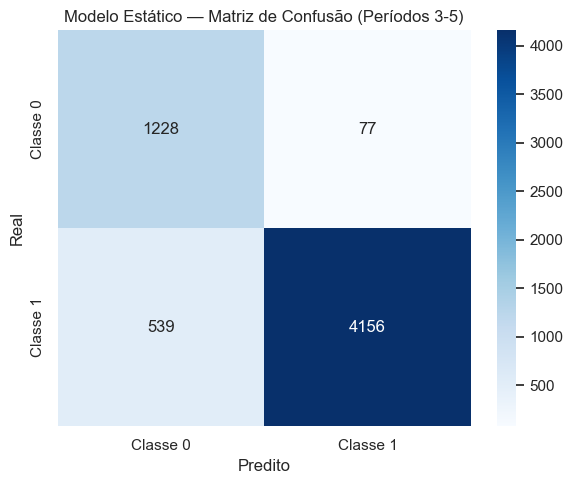

In [4]:
# Matriz de confusão
fig = plot_confusion_matrix(
    y_test, y_pred_test,
    title="Modelo Estático — Matriz de Confusão (Períodos 3-5)",
    save_path=Path.cwd().parent / "outputs" / "figures" / "cm_static.png",
)
plt.show()

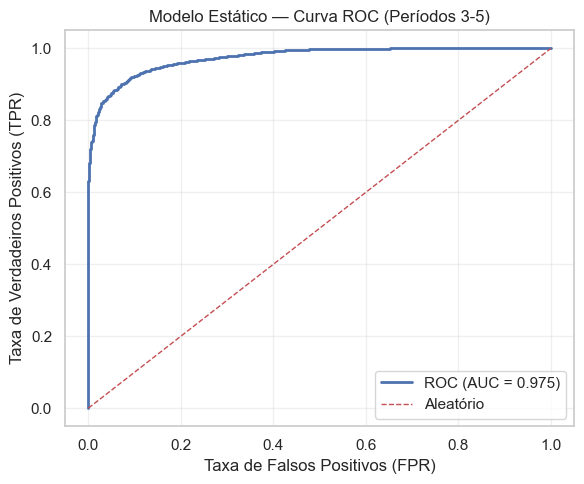

In [5]:
# Curva ROC
fig = plot_roc_curve(
    y_test, y_proba_test,
    title="Modelo Estático — Curva ROC (Períodos 3-5)",
    save_path=Path.cwd().parent / "outputs" / "figures" / "roc_static.png",
)
plt.show()

## 3. Aprendizado Incremental com `partial_fit`

Implementa o **Snippet 2** do Hands On e o conceito de **aprendizado online**
da seção *Saiba Mais*. A cada batch de dados novos, atualizamos o modelo
incrementalmente.

Conforme Lu et al. (2018), técnicas de aprendizado incremental permitem ao
modelo se adaptar ao drift sem re-treinamento completo.

In [6]:
# Cria modelo adaptativo: começa com os mesmos dados de treino
model_adaptive = AdaptiveClassifier(random_state=42)
model_adaptive.fit(X_train, y_train)

# Prepara batches dos períodos com drift
batches_X = []
batches_y = []

for period in [3, 4, 5]:
    df_p = df[df["periodo"] == period]
    X_p, y_p = preprocessor.prepare_features(df_p, fit=False)
    batches_X.append(X_p)
    batches_y.append(y_p)

print(f"Preparados {len(batches_X)} batches para aprendizado incremental")
print(f"Tamanhos: {[len(b) for b in batches_X]}")

Preparados 3 batches para aprendizado incremental
Tamanhos: [2000, 2000, 2000]


In [7]:
# Treinamento incremental batch-a-batch
# Simulação do ciclo MLOps: a cada batch, atualiza e avalia

scores_static = []
scores_adaptive = []

print("Evolução da acurácia (Modelo Estático vs Adaptativo):\n")
print(f"{'Período':<10} {'Estático':<15} {'Adaptativo':<15} {'Melhoria'}")
print("-" * 55)

for i, (X_batch, y_batch) in enumerate(zip(batches_X, batches_y)):
    period = i + 3
    
    # Avalia modelo estático (sem adaptação)
    score_s = model_static.score(X_batch, y_batch)
    scores_static.append(score_s)
    
    # Avalia modelo adaptativo ANTES do update
    score_a_before = model_adaptive.score(X_batch, y_batch)
    
    # Atualização incremental (partial_fit)
    model_adaptive.partial_fit(X_batch, y_batch)
    
    # Avalia modelo adaptativo DEPOIS do update
    score_a_after = model_adaptive.score(X_batch, y_batch)
    scores_adaptive.append(score_a_after)
    
    improvement = score_a_after - score_s
    print(f"{period:<10} {score_s:<15.4f} {score_a_after:<15.4f} {improvement:+.4f}")

Evolução da acurácia (Modelo Estático vs Adaptativo):

Período    Estático        Adaptativo      Melhoria
-------------------------------------------------------
3          0.8950          0.9185          +0.0235
4          0.9110          0.9265          +0.0155
5          0.8860          0.9555          +0.0695


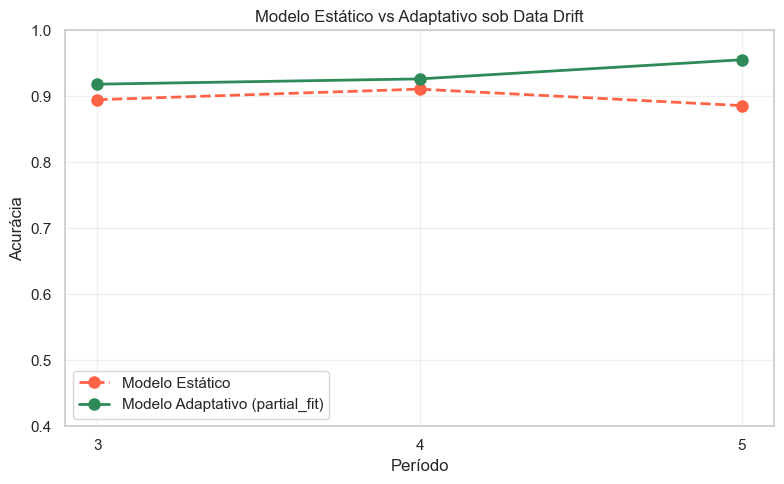

In [8]:
# Gráfico comparativo: Estático vs Adaptativo
fig, ax = plt.subplots(figsize=(8, 5))
periods = [3, 4, 5]

ax.plot(periods, scores_static, "o--", color="tomato", linewidth=2, 
        markersize=8, label="Modelo Estático")
ax.plot(periods, scores_adaptive, "o-", color="seagreen", linewidth=2, 
        markersize=8, label="Modelo Adaptativo (partial_fit)")

ax.set_xlabel("Período")
ax.set_ylabel("Acurácia")
ax.set_title("Modelo Estático vs Adaptativo sob Data Drift")
ax.set_xticks(periods)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.0)

fig.tight_layout()
fig.savefig(Path.cwd().parent / "outputs" / "figures" / "static_vs_adaptive.png", 
            dpi=150, bbox_inches="tight")
plt.show()

## 4. Ciclo MLOps: Detecção de Drift + Re-treinamento Automático

Combinamos o detector KS com o partial_fit para simular um pipeline
automatizado: **quando drift é detectado, o modelo se atualiza**.

Conforme Sculley et al. (2015), não monitorar modelos equivale a 
contrair uma **dívida técnica oculta**.

In [9]:
# Modelo com detecção integrada
model_mlops = AdaptiveClassifier(random_state=42)
model_mlops.fit(X_train, y_train)

detector = DriftDetector(alpha=0.05)

result = train_with_drift_detection(
    clf=model_mlops,
    detector=detector,
    X_reference=X_train,
    X_batches=batches_X,
    y_batches=batches_y,
    feature_names=DataPreprocessor.FEATURE_NAMES,
)

print("Log do Pipeline MLOps (Detecção + Adaptação):\n")
for entry in result["drift_log"]:
    period = entry["batch"] + 2  # batch 1 = período 3
    print(f"  Período {period}:")
    print(f"    Drift detectado: {entry['drift_detected']}")
    print(f"    Features com drift: {entry['features_with_drift']}")
    print(f"    Ação: {entry['action']}")
    print()

Log do Pipeline MLOps (Detecção + Adaptação):

  Período 3:
    Drift detectado: True
    Features com drift: 5
    Ação: partial_fit

  Período 4:
    Drift detectado: True
    Features com drift: 5
    Ação: partial_fit

  Período 5:
    Drift detectado: True
    Features com drift: 5
    Ação: partial_fit



## 5. Avaliação Final: Modelo Adaptativo

Avaliamos o modelo adaptativo nos dados de teste para confirmar
que o aprendizado incremental mitiga a degradação.

In [10]:
# Métricas finais do modelo adaptativo
y_pred_adaptive = model_adaptive.predict(X_test)
y_proba_adaptive = model_adaptive.predict_proba(X_test)[:, 1]

metrics_adaptive = calculate_metrics(y_test, y_pred_adaptive, y_proba_adaptive)

print("Comparação de Métricas (Teste — Períodos 3-5):\n")
print(f"{'Métrica':<15} {'Estático':<15} {'Adaptativo':<15} {'Δ'}")
print("-" * 55)

for key in ["accuracy", "precision", "recall", "f1", "auc"]:
    s = metrics_static.get(key, 0)
    a = metrics_adaptive.get(key, 0)
    print(f"{key:<15} {s:<15.4f} {a:<15.4f} {a - s:+.4f}")

Comparação de Métricas (Teste — Períodos 3-5):

Métrica         Estático        Adaptativo      Δ
-------------------------------------------------------
accuracy        0.8973          0.9375          +0.0402
precision       0.9818          0.9643          -0.0175
recall          0.8852          0.9555          +0.0703
f1              0.9310          0.9599          +0.0289
auc             0.9747          0.9827          +0.0080


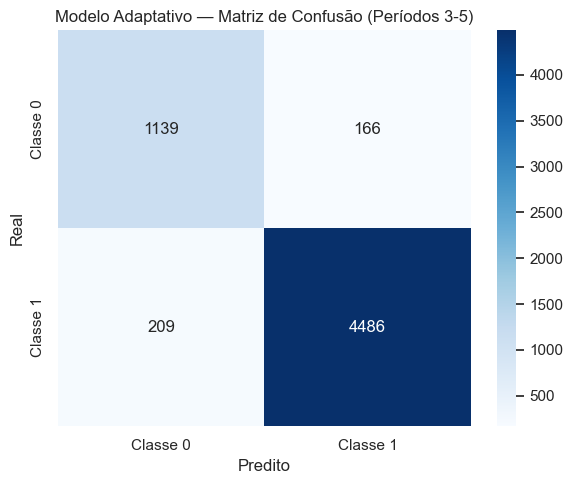

In [11]:
# Matriz de confusão do modelo adaptativo
fig = plot_confusion_matrix(
    y_test, y_pred_adaptive,
    title="Modelo Adaptativo — Matriz de Confusão (Períodos 3-5)",
    save_path=Path.cwd().parent / "outputs" / "figures" / "cm_adaptive.png",
)
plt.show()

In [12]:
# Salva modelo adaptativo e métricas finais
save_model(model_adaptive, Path.cwd().parent / "outputs" / "models" / "model_adaptive.joblib")

save_metrics(
    {
        "static": metrics_static,
        "adaptive": metrics_adaptive,
        "scores_static_by_period": dict(zip([3, 4, 5], scores_static)),
        "scores_adaptive_by_period": dict(zip([3, 4, 5], scores_adaptive)),
    },
    Path.cwd().parent / "outputs" / "logs" / "comparison_metrics.json",
)

print("Modelos e métricas salvos com sucesso!")

Modelos e métricas salvos com sucesso!


## 6. Histórico de Aprendizado Incremental

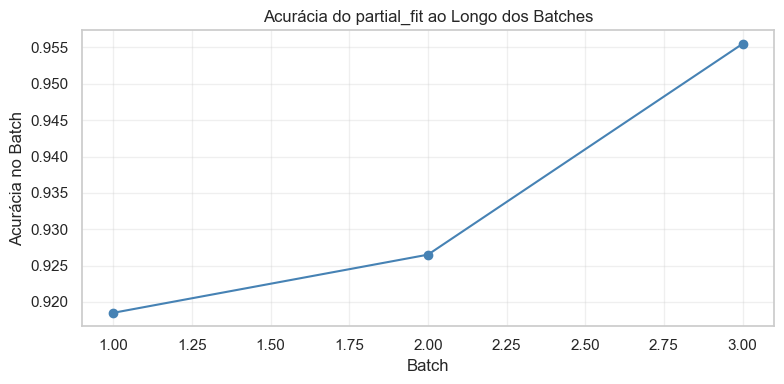

In [13]:
# Evolução da acurácia batch-a-batch durante partial_fit
history = model_adaptive.history

fig, ax = plt.subplots(figsize=(8, 4))
batch_accs = [h["batch_accuracy"] for h in history]
ax.plot(range(1, len(batch_accs) + 1), batch_accs, "o-", color="steelblue")
ax.set_xlabel("Batch")
ax.set_ylabel("Acurácia no Batch")
ax.set_title("Acurácia do partial_fit ao Longo dos Batches")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(Path.cwd().parent / "outputs" / "figures" / "incremental_history.png", 
            dpi=150, bbox_inches="tight")
plt.show()

## Resumo

Neste notebook concluímos a **Aula 1 — Fundamentos do Data Drift em ML**:

1. **Modelo estático** sofre degradação progressiva sob data drift
2. **Aprendizado incremental** (`partial_fit`) permite adaptação contínua
3. **Detecção de drift** (teste KS) combinada com re-treinamento simula
   o ciclo de **MLOps**: monitorar → detectar → adaptar
4. O modelo adaptativo obtém melhor desempenho nos dados com drift

### Conceitos-Chave Implementados:
- Data Drift (Covariate Shift): $P_{\text{treino}}(X) \neq P_{\text{produção}}(X)$
- Teste KS: $D = \sup_x |F_{\text{ref}}(x) - F_{\text{prod}}(x)|$
- Aprendizado incremental com `SGDClassifier.partial_fit()`
- Ciclo MLOps: monitorar → detectar → adaptar

### Referências
- Widmer, G. & Kubat, M. (1996). Learning in the presence of concept drift.
- Gama, J. et al. (2014). A Survey on Concept Drift Adaptation. ACM.
- Lu, J. et al. (2018). Learning under Concept Drift: A Review. IEEE TKDE.
- Sculley, D. et al. (2015). Hidden Technical Debt in ML Systems. NeurIPS.
- Pang, G. et al. (2023). AI Aging. Nature Communications.